Import necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

# Prepare datasets

This is pretty much what have been shown in class

## Download datasets

In [ ]:
# Delete the datasets (In case already loaded)
!rm -rf SDSS_QSO.dat SDSS_stars.csv

# Download datasets from course github
!wget https://raw.githubusercontent.com/fforster/AS4501/27efaa02f86a86eb51a8e7993d5e738aca43e62f/ML_Unsupervised/data/SDSS_QSO.dat
!wget https://raw.githubusercontent.com/fforster/AS4501/27efaa02f86a86eb51a8e7993d5e738aca43e62f/ML_Unsupervised/data/SDSS_stars.csv

--2025-04-30 17:13:28--  https://raw.githubusercontent.com/fforster/AS4501/27efaa02f86a86eb51a8e7993d5e738aca43e62f/ML_Unsupervised/data/SDSS_QSO.dat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8749579 (8.3M) [text/plain]
Saving to: ‘SDSS_QSO.dat’

SDSS_QSO.dat        100%[===================>]   8.34M  --.-KB/s    in 0.08s   

2025-04-30 17:13:29 (107 MB/s) - ‘SDSS_QSO.dat’ saved [8749579/8749579]

--2025-04-30 17:13:29--  https://raw.githubusercontent.com/fforster/AS4501/27efaa02f86a86eb51a8e7993d5e738aca43e62f/ML_Unsupervised/data/SDSS_stars.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:44

## Load datasets and join them

In [ ]:
# Load SDSS_stars.csv
stars = pd.read_csv('SDSS_stars.csv')

# Load SDSS_QSO.dat
qsos = pd.read_csv('SDSS_QSO.dat', sep='\s+', index_col = "SDSS")

In [ ]:
# Prepare DataSet
stars["cat"] = "star" # Star class + colors
stars["u-g"] = stars.u_mag - stars.g_mag
stars["g-r"] = stars.g_mag - stars.r_mag
stars["r-i"] = stars.r_mag - stars.i_mag
stars["i-z"] = stars.i_mag - stars.z_mag

qsos["cat"] = "QSO" # QSO class + colors
qsos["u-g"] = qsos.u_mag - qsos.g_mag
qsos["g-r"] = qsos.g_mag - qsos.r_mag
qsos["r-i"] = qsos.r_mag - qsos.i_mag
qsos["i-z"] = qsos.i_mag - qsos.z_mag


# Selec only the columns we want
sel_cols = ["u-g", "g-r", "r-i", "i-z", "cat"]
data = pd.concat([stars[sel_cols], qsos[sel_cols]])
data["cat"] = data["cat"].astype("category")
data

,u-g,g-r,r-i,i-z,cat
0,2.565130,1.140717,0.454219,0.282032,star
1,1.219900,0.465681,0.175379,0.060576,star
2,1.268289,0.397114,0.194193,0.031632,star
3,1.963503,0.817444,0.281929,0.179737,star
4,1.235975,0.518007,0.212653,0.058380,star
...,...,...,...,...,...
235958.21+005139.8,0.252000,0.210000,0.237000,0.112000,QSO
235958.66-011225.2,0.076000,0.060000,0.210000,0.016000,QSO
235958.72+003345.3,0.003000,0.163000,0.329000,0.028000,QSO
235959.06-090944.0,0.030000,0.234000,0.021000,0.047000,QSO


We can get a quick statistical description of the df using

```
df.describe()
```



In [ ]:
data.describe()

,u-g,g-r,r-i,i-z
count,82429.000000,82429.000000,82429.000000,82429.000000
mean,0.535715,0.249260,0.152625,0.090630
std,0.821877,0.350443,0.178424,0.179029
min,-19.651000,-20.020000,-1.523000,-2.247000
25%,0.133000,0.059000,0.036000,-0.018000
50%,0.266000,0.176000,0.144983,0.071000
75%,0.502000,0.324000,0.245000,0.179000
max,7.178000,5.548000,3.228000,19.666000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82429 entries, 0 to 235959.44+000841.5
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   u-g     82429 non-null  float64 
 1   g-r     82429 non-null  float64 
 2   r-i     82429 non-null  float64 
 3   i-z     82429 non-null  float64 
 4   cat     82429 non-null  category
dtypes: category(1), float64(4)
memory usage: 5.2+ MB


## Load useful functions

This are modifications of the functions seen in class, so they can be applied to multidimentional datasets (>2 features)

In [ ]:
def make_meshgrid(x, y, z1_mean, z2_mean, h=.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1,
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))

    zz1 = np.full_like(xx, z1_mean)
    zz2 = np.full_like(xx, z2_mean)
    return xx, yy, zz1, zz2

def plot_contours(ax, clf, xx, yy, zz1, zz2, pos_label, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel(), zz1.ravel(), zz2.ravel()]) == pos_label
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

def plot_four_confusion_matrices(y_true, y_pred, le, cmap=plt.cm.Blues):
    """
    Plots four confusion matrices in one figure:
        - Raw counts
        - Normalized by prediction
        - Normalized by true
        - Normalized overall
    """
    # Decode integer labels back to original (e.g., 'star', 'QSO')
    y_true_decoded = le.inverse_transform(y_true)
    y_pred_decoded = le.inverse_transform(y_pred)

    # Create subplots
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    titles = [
        "Confusion Matrix (Counts)",
        "Confusion Matrix (Normalized by True)",
        "Confusion Matrix (Normalized by Pred)",
        "Confusion Matrix (Normalized Overall)"
    ]

    normalizations = [None, "true", "pred", "all"]

    for ax, title, norm in zip(axs.ravel(), titles, normalizations):
        ConfusionMatrixDisplay.from_predictions(
            y_true_decoded,
            y_pred_decoded,
            cmap=cmap,
            normalize=norm,
            ax=ax,
            colorbar=True,
            values_format='.2%' if norm else None
        )
        ax.set_title(title)

    plt.tight_layout()
    plt.show()




# Split dataset into training - validation and test set

In this case, we do not split into a validation set, as it is later done by the model trainning process. But if you are not going to use a method such as Cross-Validation, yuou should also split thour trainning set into trainning and validation:

```
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=8)
```



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data.drop("cat", axis=1), data["cat"], test_size=0.2, random_state=8)

In [ ]:
# Tokenize the labels

from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(data.cat)
print(le.classes_)
y_train = le.transform(y_train)
y_test = le.transform(y_test)

['QSO' 'star']


In [ ]:
y_test

array([0, 0, 0, ..., 0, 0, 0])

# Data analysis

Before going into the trainning process, it is a good pracice to perform at least a quick Data analysis, in order to have a general idea of what kind of data and problem we are working with. For example, here we see that the dataset is highly imbalanced

<ipython-input-11-e4a785a2c71f>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="cat", palette="Set2")


<Axes: xlabel='cat', ylabel='count'>

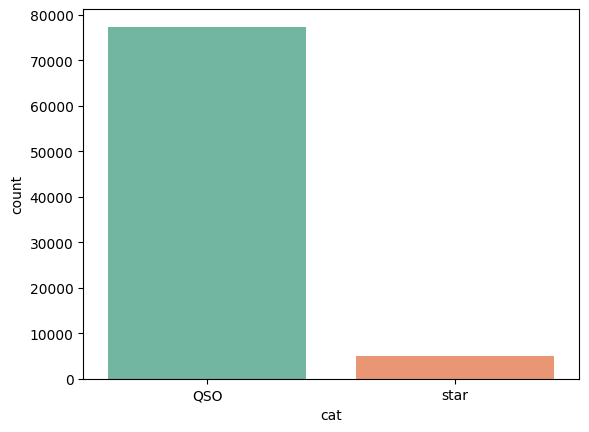

In [ ]:
sns.countplot(data=data, x="cat", palette="Set2")

To make easier the analysis, we can make use of handful libraries such as seaborn. For example here we can see a map correlation between all the data features for a sample of 5000 elements (this as it takes a while to handle all our data)

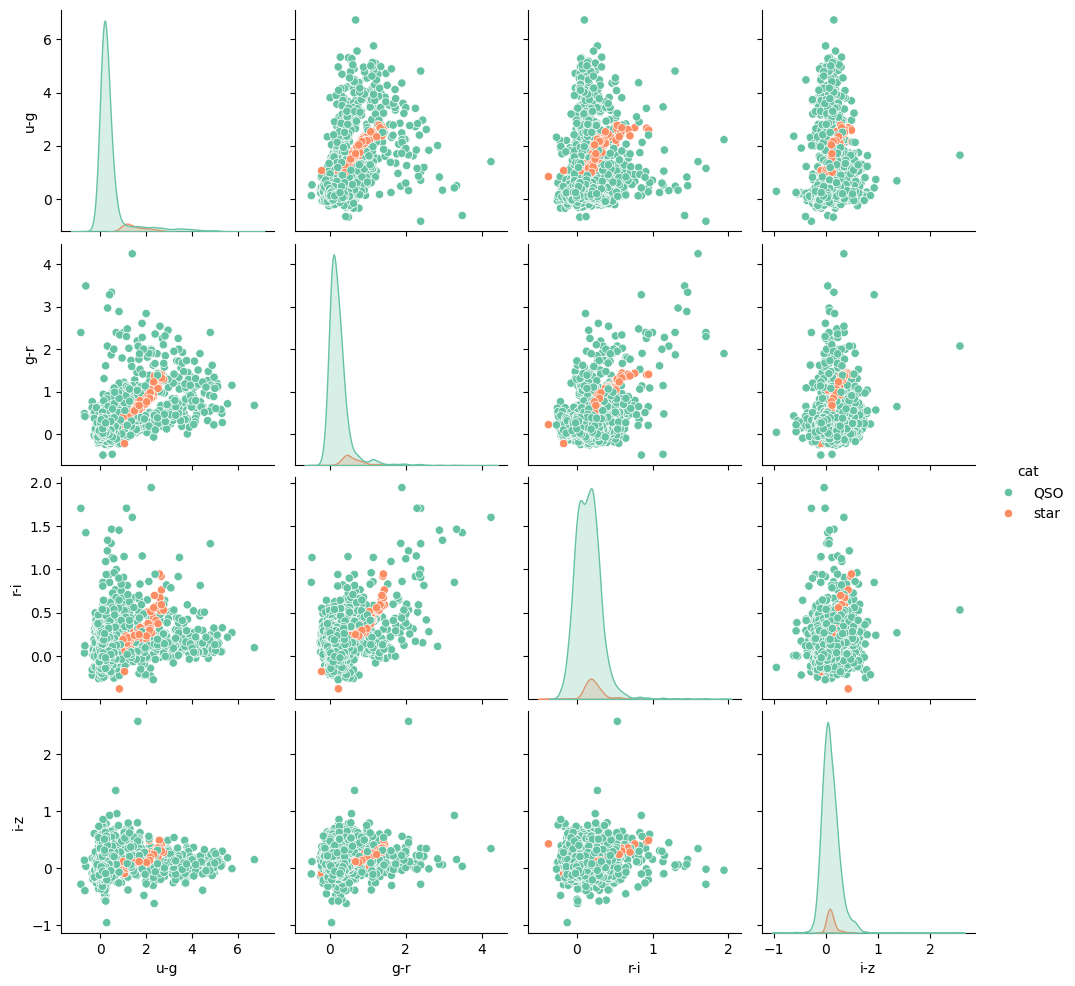

In [ ]:
sns.pairplot(data.sample(5000), hue="cat", kind='scatter', palette="Set2")

# Train **unbalanced** model


First, we train the model with no major consideration of the unbalance of the dataset. We go for a RandomForest model, due to its capacity to adapt to very different kind of datasets with a good performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_simple = RandomForestClassifier(n_estimators=100, random_state=8)
rf_simple.fit(X_train, y_train)

y_pred = rf_simple.predict(X_test)
y_proba = rf_simple.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


(-2.0, 6.0)

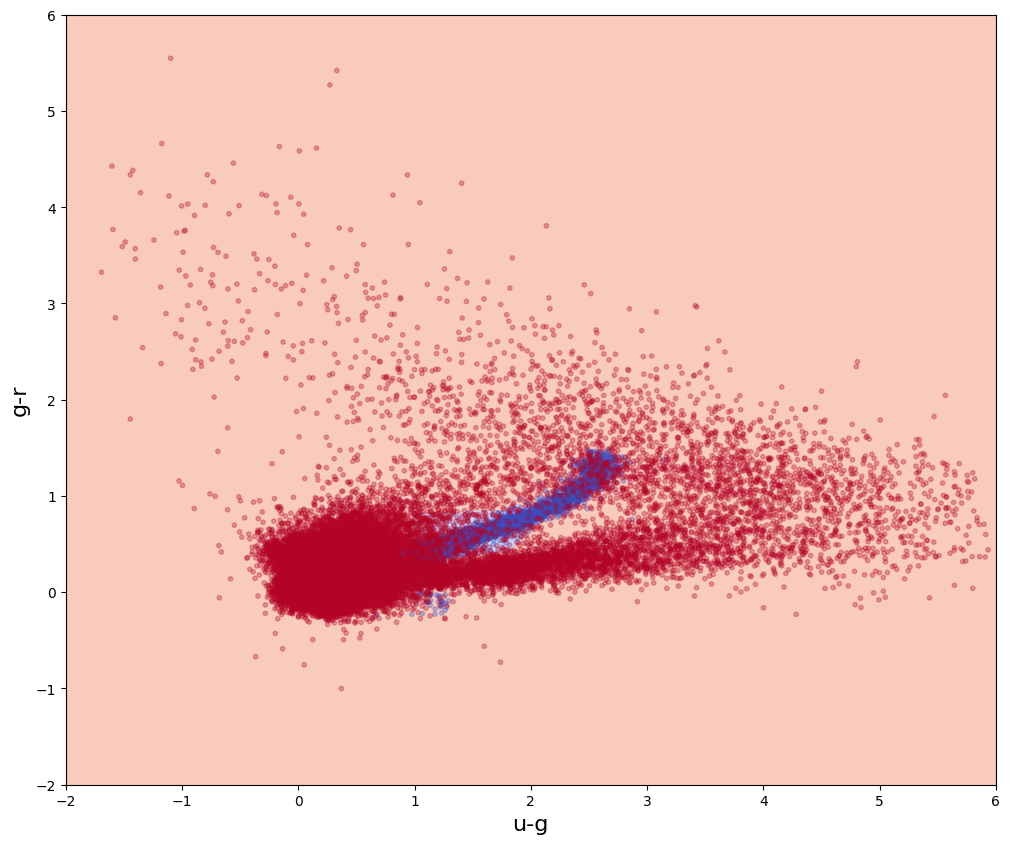

In [ ]:
fig, ax = plt.subplots(figsize = (12, 10))
xx, yy, zz1, zz2 = make_meshgrid(data["u-g"], data["g-r"], data["r-i"].mean(), data["i-z"].mean())
plot_contours(ax, rf_simple, xx, yy, zz1, zz2, le.transform(["QSO"]),
                  cmap=plt.cm.coolwarm, alpha=0.5)
ax.scatter(data["u-g"], data["g-r"], c=(data.cat=='QSO'), cmap=plt.cm.coolwarm, s=10, edgecolors=None, alpha = 0.3)
ax.set_xlabel("u-g", fontsize=16)
ax.set_ylabel("g-r", fontsize=16)
ax.set_xlim(-2, 6)
ax.set_ylim(-2, 6)

In [ ]:
print("Clasification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Clasification Report:
              precision    recall  f1-score   support

         QSO       1.00      1.00      1.00     15481
        star       0.98      0.97      0.98      1005

    accuracy                           1.00     16486
   macro avg       0.99      0.99      0.99     16486
weighted avg       1.00      1.00      1.00     16486



A good score to actually have an idea of how well the model did, is using the ROC AUC (Area Under Curve). You can check [this link](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc?hl=es-419) for more information, as well as the course docuemntation.

In [ ]:
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

ROC AUC Score: 0.9998


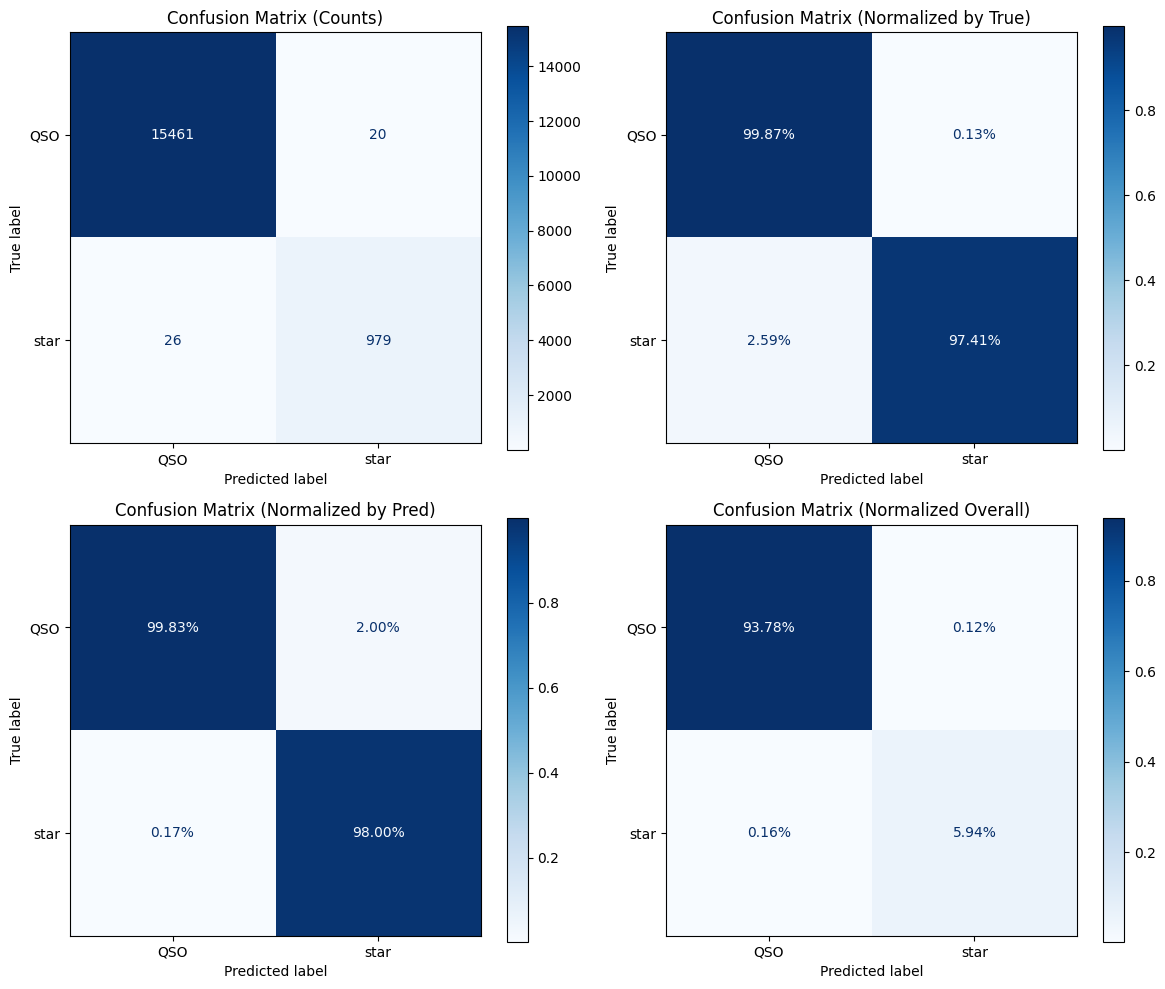

In [ ]:
plot_four_confusion_matrices(y_test, y_pred, le)

Here, each matrix provides it's own information. The first case (Counts), shows individually how the model classified each data point in the classes. The (Normalized by True), normalizes the first matrix by the True values, this tell us, "If you know a point belongs to a class, what is the likelihood that the model accerts". While the third matrix (Normalized by Pred), corresponds to the first matrix normalized by the predictions of the model. In this case, this tell us, "If the give us a prediction from a datapoint, how likely is that it was indeed from that class". Note that the third matrix, is what bring us more information, as in practice, we do not know the True labels, and therefore, give us an idea of how well the model will perform.

The forth matrix holds no major meaning.

## Gridsearch

Instead of blindly look for the model hyperparameters, we can perform a grid search over a list of different hyperparameters. This allows for a more complete and robust exploration, and simplifies the process of exploring by ourselves.

### Sklearn

Sklearn provides a very simple, but useful gridsearch

In [ ]:
from sklearn.model_selection import GridSearchCV

# First we define a basic model
rf = RandomForestClassifier(random_state=8)

# The hyperparameters from which we will explore
param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy']
}

# initiare the gridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=8), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc', verbose=1)

ROC AUC Score: 0.9999
Best parameters found by grid search: {'criterion': 'entropy', 'n_estimators': 200}

 Clasification Report on Test Set:
              precision    recall  f1-score   support

         QSO       1.00      1.00      1.00     15481
        star       0.98      0.98      0.98      1005

    accuracy                           1.00     16486
   macro avg       0.99      0.99      0.99     16486
weighted avg       1.00      1.00      1.00     16486



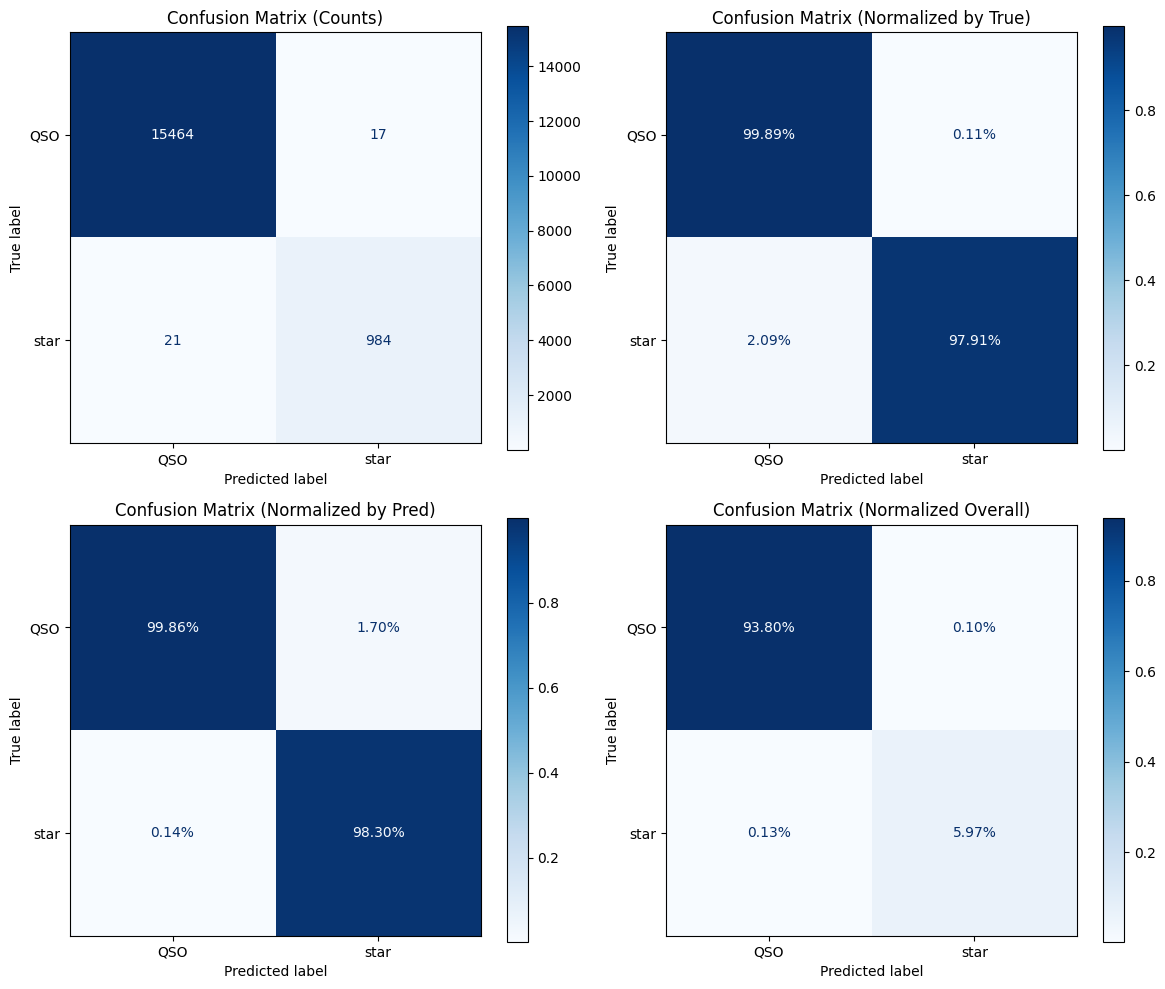

In [ ]:
# Evaluate model
grid_search.best_estimator_.fit(X_train, y_train)
y_pred_simple_sk = grid_search.best_estimator_.predict(X_test)
y_proba_simple_sk = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_simple_sk):.4f}")


print("Best parameters found by grid search:", grid_search.best_params_)
print("\n Clasification Report on Test Set:")
print(classification_report(y_test, y_pred_simple_sk, target_names=le.classes_))

plot_four_confusion_matrices(y_test, y_pred_simple_sk, le)

### Optuna

Besides Sklearn, you may also be interested in using optuna, which is a library specialized in the search of hyperparameters. Searching in a grid, is pretty the same as before, but we need to define by hand the "loss" or "objective" function.

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 16.1 MB/s eta 0:00:00


In [ ]:
import optuna

# Define objective function for Optuna
def objective(trial):
    # Suggest values for each hyperparameter
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [50, 100, 200]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 8
    }

    model = RandomForestClassifier(**params)

    # Use cross-validation on resampled data
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return np.mean(scores)

search_space = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy']
}

# Create a study to maximize ROC AUC
study = optuna.create_study(sampler=optuna.samplers.GridSampler(search_space), direction='maximize')
study.optimize(objective, n_trials=3*2)

[I 2025-04-30 17:17:12,027] A new study created in memory with name: no-name-1bb8a0d6-5374-4c54-b342-872b71341500
[I 2025-04-30 17:18:07,352] Trial 0 finished with value: 0.999309619291475 and parameters: {'n_estimators': 200, 'criterion': 'entropy'}. Best is trial 0 with value: 0.999309619291475.
[I 2025-04-30 17:18:57,007] Trial 1 finished with value: 0.9992914571041449 and parameters: {'n_estimators': 200, 'criterion': 'gini'}. Best is trial 0 with value: 0.999309619291475.
[I 2025-04-30 17:19:25,520] Trial 2 finished with value: 0.9989119371387275 and parameters: {'n_estimators': 100, 'criterion': 'gini'}. Best is trial 0 with value: 0.999309619291475.
[I 2025-04-30 17:19:39,510] Trial 3 finished with value: 0.9988879458625067 and parameters: {'n_estimators': 50, 'criterion': 'entropy'}. Best is trial 0 with value: 0.999309619291475.
[I 2025-04-30 17:19:54,403] Trial 4 finished with value: 0.9986512795423266 and parameters: {'n_estimators': 50, 'criterion': 'gini'}. Best is trial 0


Best Parameters Found by Optuna: {'n_estimators': 200, 'criterion': 'entropy'}
Best ROC AUC Score from CV: 0.999309619291475

Classification Report on Test Set:
              precision    recall  f1-score   support

         QSO       1.00      1.00      1.00     15481
        star       0.98      0.98      0.98      1005

    accuracy                           1.00     16486
   macro avg       0.99      0.99      0.99     16486
weighted avg       1.00      1.00      1.00     16486

Test ROC AUC Score: 0.999862


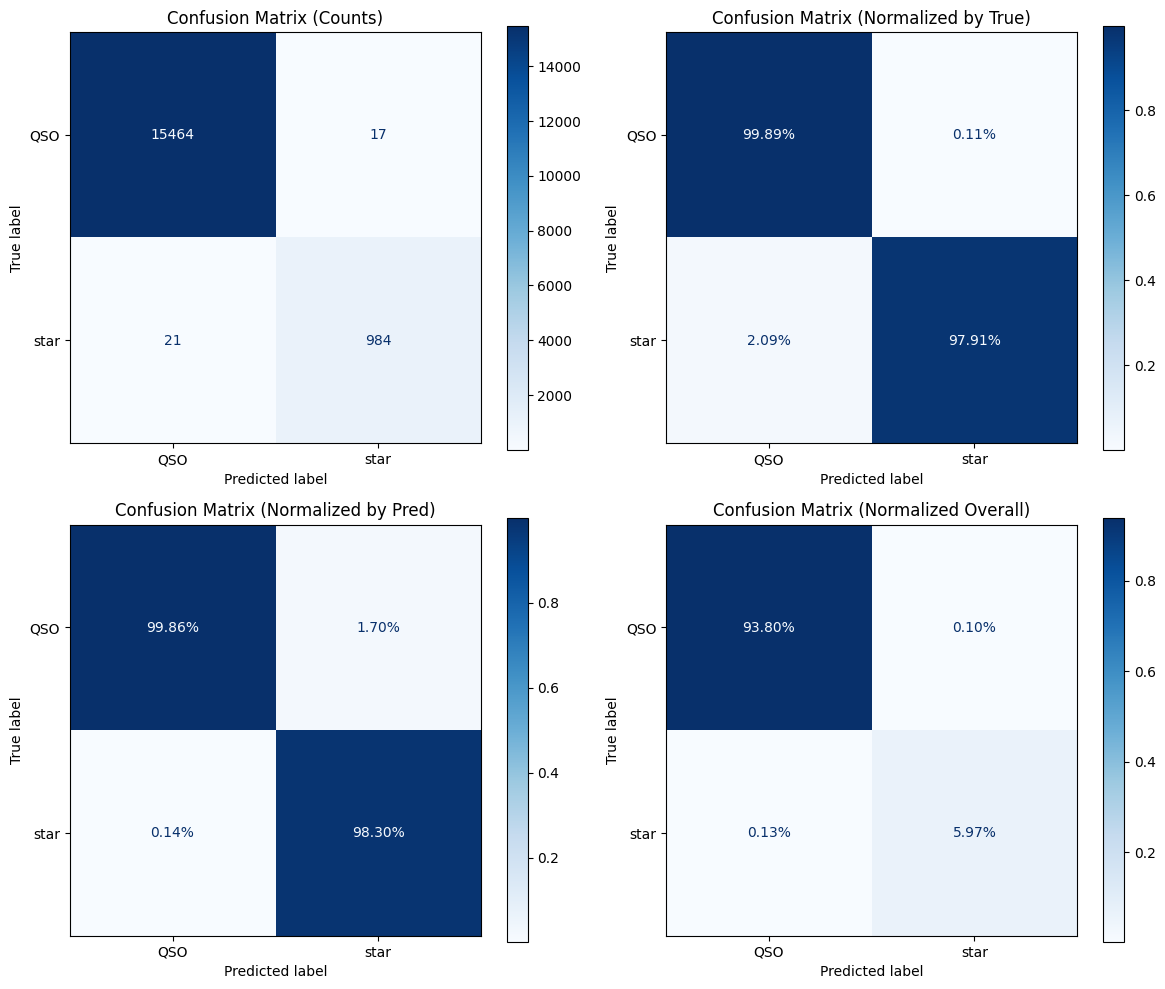

In [ ]:
# Get best parameters
best_params = study.best_params
print("\nBest Parameters Found by Optuna:", best_params)
print("Best ROC AUC Score from CV:", study.best_value)

# Train final model with best parameters
best_model = RandomForestClassifier(**best_params, random_state=8)
best_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_simple_optuna = best_model.predict(X_test)
y_proba_simple_optuna = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_simple_optuna, target_names=le.classes_))

print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_proba_simple_optuna):.6f}")

# Confusion Matrix
plot_four_confusion_matrices(y_test, y_pred_simple_optuna, le)

You can check that both models coincide

In [ ]:
print(f"Test ROC AUC Score (sklearn): {roc_auc_score(y_test, y_proba_simple_sk):.6f}")
print(f"Test ROC AUC Score (optuna): {roc_auc_score(y_test, y_proba_simple_optuna):.6f}")

Test ROC AUC Score (sklearn): 0.999862
Test ROC AUC Score (optuna): 0.999862


# Undersampling

Here we use a method, in which we take a subsample of the class more numerous, ending up with less elements for the trainning, but with around the same number of elements for class.

In [ ]:
# Create the undersample
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=8)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)


print("Class distribution after undersampling:")
print(dict(zip(le.classes_, np.bincount(y_train_rus))))

Class distribution after undersampling:
{'QSO': np.int64(3995), 'star': np.int64(3995)}


In [ ]:
def objective(trial):
    # Suggest values for each hyperparameter
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [50, 100, 200]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 8
    }

    model = RandomForestClassifier(**params)

    # Use cross-validation on resampled data
    scores = cross_val_score(model, X_train_rus, y_train_rus, cv=5, scoring='roc_auc', n_jobs=-1)
    return np.mean(scores)

search_space = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy']
}


study = optuna.create_study(sampler=optuna.samplers.GridSampler(search_space), direction='maximize')
study.optimize(objective, n_trials=3*2)  # You can increase this number

[I 2025-04-30 17:20:43,374] A new study created in memory with name: no-name-4f074b57-cdd7-4a8c-868f-a1bb1af22b27
[I 2025-04-30 17:20:56,404] Trial 0 finished with value: 0.9996132524855067 and parameters: {'n_estimators': 200, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9996132524855067.
[I 2025-04-30 17:21:08,379] Trial 1 finished with value: 0.9994716486972919 and parameters: {'n_estimators': 200, 'criterion': 'gini'}. Best is trial 0 with value: 0.9996132524855067.
[I 2025-04-30 17:21:14,035] Trial 2 finished with value: 0.9993616864635237 and parameters: {'n_estimators': 100, 'criterion': 'gini'}. Best is trial 0 with value: 0.9996132524855067.
[I 2025-04-30 17:21:17,021] Trial 3 finished with value: 0.999143015126856 and parameters: {'n_estimators': 50, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9996132524855067.
[I 2025-04-30 17:21:21,078] Trial 4 finished with value: 0.999016135626354 and parameters: {'n_estimators': 50, 'criterion': 'gini'}. Best is tria


Best Parameters Found by Optuna: {'n_estimators': 100, 'criterion': 'entropy'}
Best ROC AUC Score from CV: 0.999613565768224

Classification Report on Test Set:
              precision    recall  f1-score   support

         QSO       1.00      0.99      1.00     15481
        star       0.88      1.00      0.94      1005

    accuracy                           0.99     16486
   macro avg       0.94      0.99      0.97     16486
weighted avg       0.99      0.99      0.99     16486

Test ROC AUC Score: 0.9997


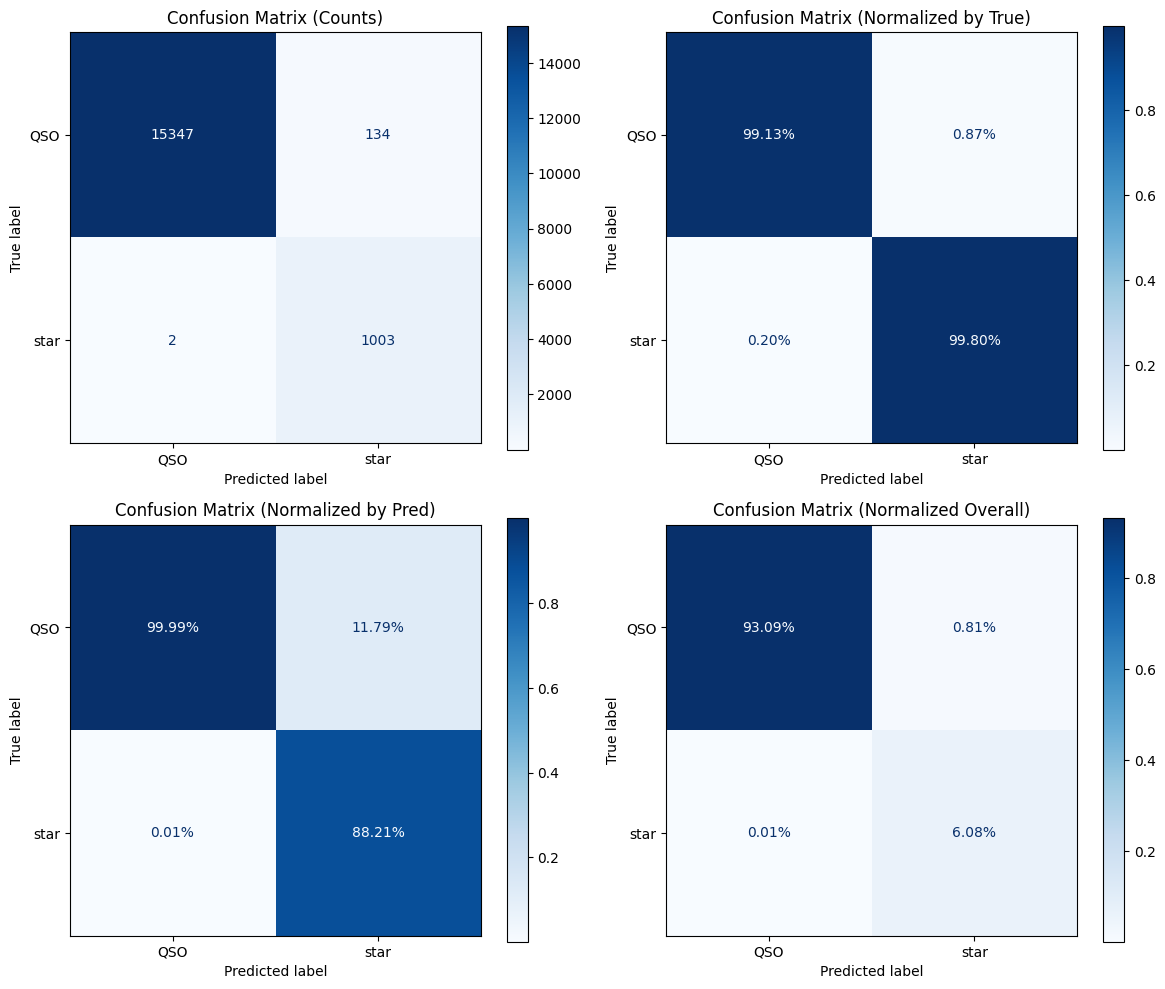

In [ ]:
# Get best parameters
best_params = study.best_params
print("\nBest Parameters Found by Optuna:", best_params)
print("Best ROC AUC Score from CV:", study.best_value)

# Train final model with best parameters
best_model = RandomForestClassifier(**best_params, random_state=8)
best_model.fit(X_train_rus, y_train_rus)

# Evaluate on test set
y_pred_rus = best_model.predict(X_test)
y_proba_rus = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_rus, target_names=le.classes_))

print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_proba_rus):.4f}")

# Confusion Matrix
plot_four_confusion_matrices(y_test, y_pred_rus, le)

# Oversampling

Alternatively, we can do the inverse, that is, expand and create "sythetic" data for the classes with fewer elements.

In [ ]:
# Create the undersample
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=8)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)


print("Class distribution after undersampling:")
print(dict(zip(le.classes_, np.bincount(y_train_ros))))

Class distribution after undersampling:
{'QSO': np.int64(61948), 'star': np.int64(61948)}


In [ ]:
def objective(trial):
    # Suggest values for each hyperparameter
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [50, 100, 200]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 8
    }

    model = RandomForestClassifier(**params)

    # Use cross-validation on resampled data
    scores = cross_val_score(model, X_train_ros, y_train_ros, cv=5, scoring='roc_auc', n_jobs=-1)
    return np.mean(scores)

search_space = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy']
}


study = optuna.create_study(sampler=optuna.samplers.GridSampler(search_space), direction='maximize')
study.optimize(objective, n_trials=3*2)  # You can increase this number

[I 2025-04-30 17:21:29,628] A new study created in memory with name: no-name-a222485e-e49b-49e1-abfa-f02046934233
[I 2025-04-30 17:23:55,350] Trial 0 finished with value: 0.9999514044731838 and parameters: {'n_estimators': 200, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9999514044731838.
[I 2025-04-30 17:27:04,454] Trial 1 finished with value: 0.9999352226811308 and parameters: {'n_estimators': 200, 'criterion': 'gini'}. Best is trial 0 with value: 0.9999514044731838.
[I 2025-04-30 17:28:40,100] Trial 2 finished with value: 0.9998949222794179 and parameters: {'n_estimators': 100, 'criterion': 'gini'}. Best is trial 0 with value: 0.9999514044731838.
[I 2025-04-30 17:29:15,687] Trial 3 finished with value: 0.9998869561410627 and parameters: {'n_estimators': 50, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9999514044731838.
[I 2025-04-30 17:30:03,707] Trial 4 finished with value: 0.9998546055918707 and parameters: {'n_estimators': 50, 'criterion': 'gini'}. Best is tr


Best Parameters Found by Optuna: {'n_estimators': 200, 'criterion': 'entropy'}
Best ROC AUC Score from CV: 0.9999514044731838

Classification Report on Test Set:
              precision    recall  f1-score   support

         QSO       1.00      1.00      1.00     15481
        star       0.98      0.99      0.98      1005

    accuracy                           1.00     16486
   macro avg       0.99      0.99      0.99     16486
weighted avg       1.00      1.00      1.00     16486

Test ROC AUC Score: 0.9999


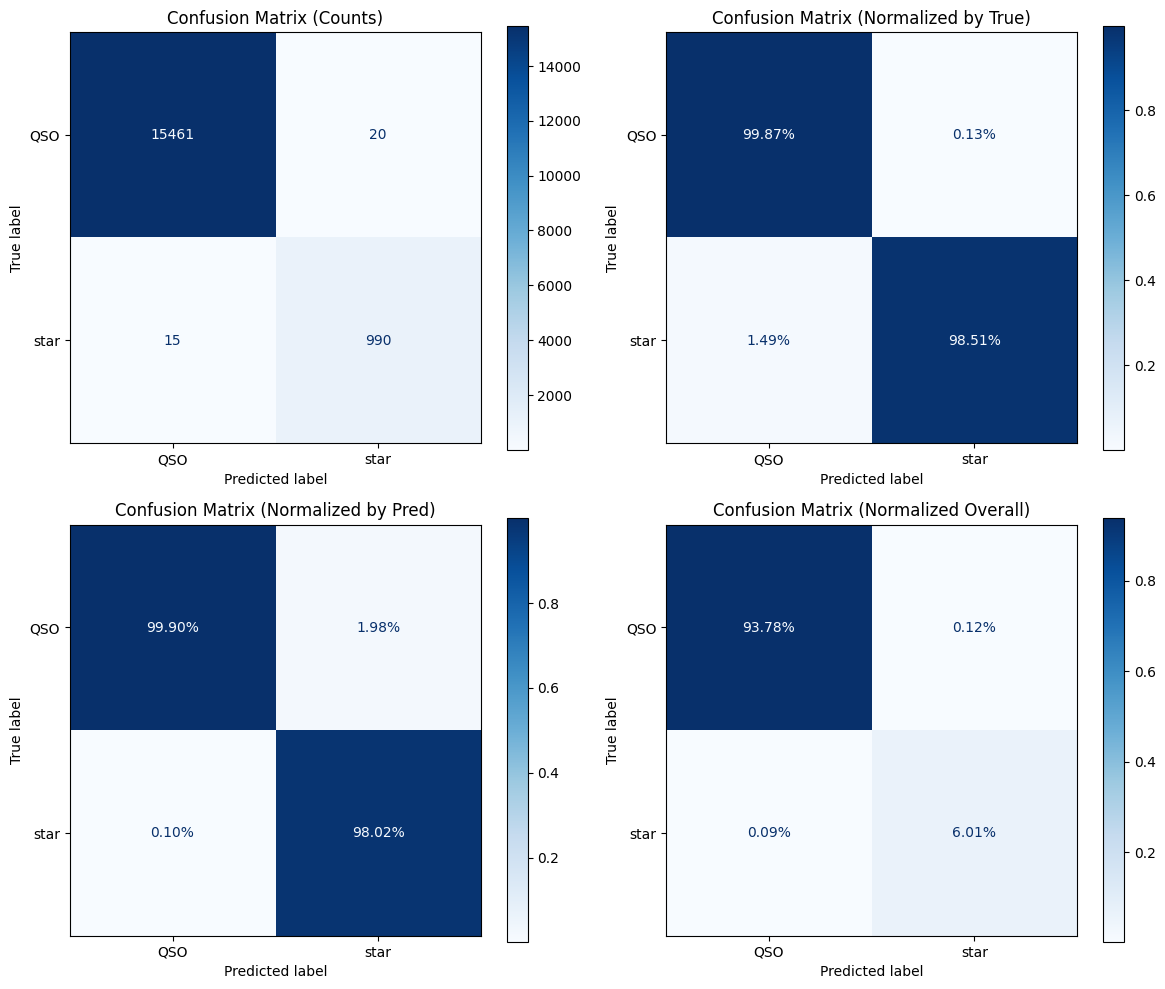

In [ ]:
# Get best parameters
best_params = study.best_params
print("\nBest Parameters Found by Optuna:", best_params)
print("Best ROC AUC Score from CV:", study.best_value)

# Train final model with best parameters
best_model = RandomForestClassifier(**best_params, random_state=8)
best_model.fit(X_train_ros, y_train_ros)

# Evaluate on test set
y_pred_ros = best_model.predict(X_test)
y_proba_ros = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_ros, target_names=le.classes_))

print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_proba_ros):.4f}")

# Confusion Matrix
plot_four_confusion_matrices(y_test, y_pred_ros, le)

# RandomForest Balanced

There are other numerous approaches to handle Imbalanced data, and it's recommended to check the library [imblearn](https://imbalanced-learn.org/stable/) for more details. Here we use a "balanced" version of RandomForest. This model, creates weights for each class, giving a greater weight (importance) to clasess with fewer elements [reference](https://www.researchgate.net/publication/369458562_Class_Weighting_Technique_to_Deal_with_Imbalanced_Class_Problem_in_Machine_Learning_Methodological_Research).

In simpler words, this makes that, missclassifications for tha classes with less elements, lead to a greater error, pushing the model to avoid their missclassification, and in general, leads to a better result overall.

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(random_state=8)
brf.fit(X_train, y_train)

y_pred_brf = brf.predict(X_test)
y_proba_brf = brf.predict_proba(X_test)[:,1]


Classification Report on Test Set:
              precision    recall  f1-score   support

         QSO       1.00      0.99      1.00     15481
        star       0.92      0.99      0.96      1005

    accuracy                           0.99     16486
   macro avg       0.96      0.99      0.98     16486
weighted avg       0.99      0.99      0.99     16486

Test ROC AUC Score: 0.9998


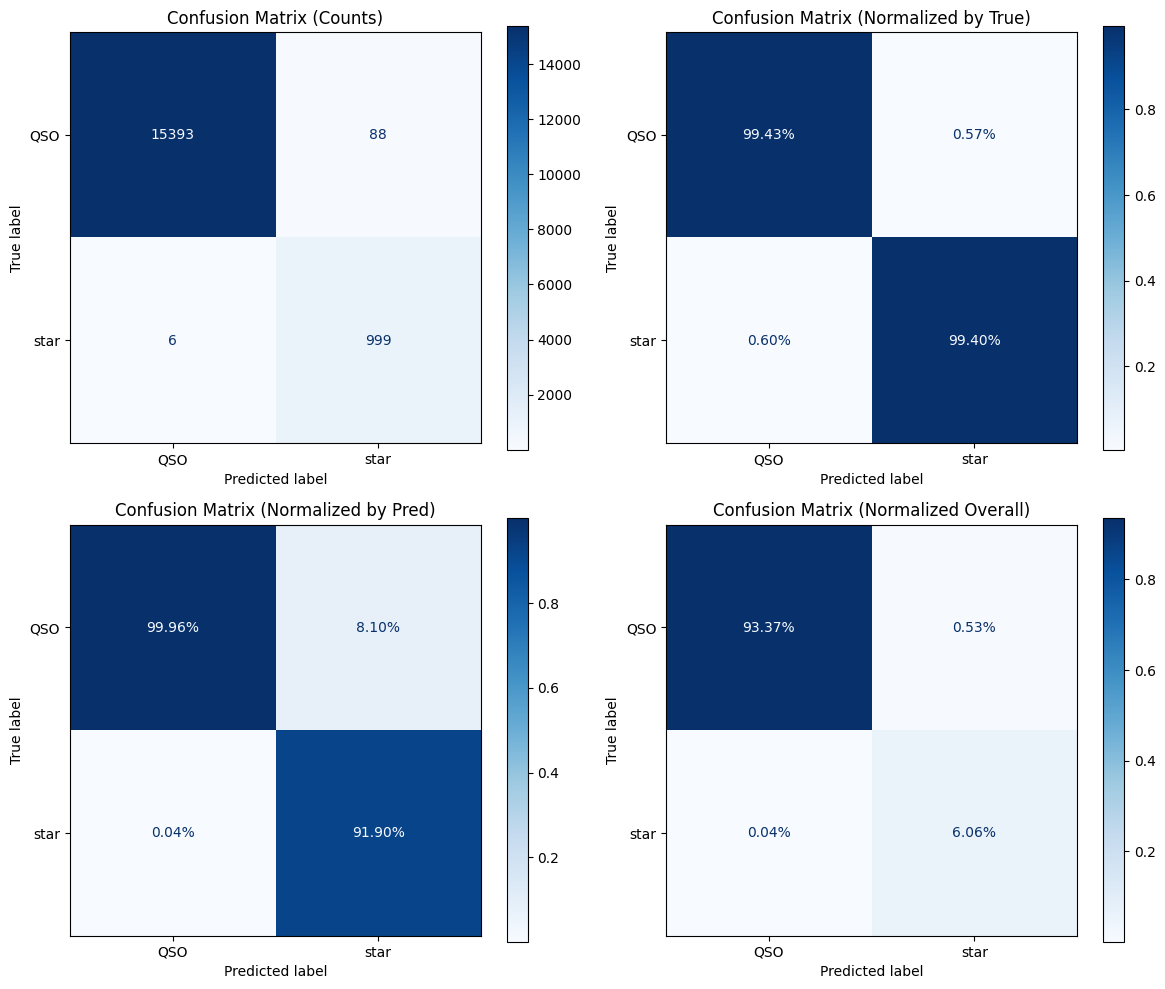

In [ ]:
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_brf, target_names=le.classes_))

print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_proba_brf):.4f}")

# Confusion Matrix
plot_four_confusion_matrices(y_test, y_pred_brf, le)

Here we use optuna as well, but we take advantage of its capabilities, and do not create a closed grid-search, but instead, allow it to explore a space. Note that the number of n_trials will define how much hyperparameter configurations the model is going to explore. This have a great impact, when dealing with complex models, such as Neuronal Networks and Transformers. Also, Optuna provides a pretty handful [visualization of the results](https://optuna.readthedocs.io/en/stable/reference/visualization/index.html).

In [ ]:
def objective(trial):
    # Suggest values for each hyperparameter
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'sampling_strategy': trial.suggest_categorical('sampling_strategy', ['all', 'not minority', 'not majority']),
        'random_state': 8
    }

    model = BalancedRandomForestClassifier(**params)

    # Use cross-validation on resampled data
    scores = cross_val_score(model, X_train_ros, y_train_ros, cv=5, scoring='roc_auc', n_jobs=-1)
    return np.mean(scores)



study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)  # You can increase this number

[I 2025-04-30 17:32:06,478] A new study created in memory with name: no-name-fcae916f-697d-48f7-b080-12d17c66c26a
[I 2025-04-30 17:34:45,603] Trial 0 finished with value: 0.9999352800130159 and parameters: {'n_estimators': 117, 'criterion': 'gini', 'sampling_strategy': 'all'}. Best is trial 0 with value: 0.9999352800130159.
[I 2025-04-30 17:36:42,850] Trial 1 finished with value: 0.999927276086313 and parameters: {'n_estimators': 113, 'criterion': 'entropy', 'sampling_strategy': 'not minority'}. Best is trial 0 with value: 0.9999352800130159.
[I 2025-04-30 17:39:43,092] Trial 2 finished with value: 0.9999353041168753 and parameters: {'n_estimators': 131, 'criterion': 'gini', 'sampling_strategy': 'not minority'}. Best is trial 2 with value: 0.9999353041168753.
[I 2025-04-30 17:42:16,323] Trial 3 finished with value: 0.999951452679851 and parameters: {'n_estimators': 141, 'criterion': 'entropy', 'sampling_strategy': 'not majority'}. Best is trial 3 with value: 0.999951452679851.
[I 2025-


Best Parameters Found by Optuna: {'n_estimators': 169, 'criterion': 'gini', 'sampling_strategy': 'all'}
Best ROC AUC Score from CV: 0.9999594579086992

Classification Report on Test Set:
              precision    recall  f1-score   support

         QSO       1.00      1.00      1.00     15481
        star       0.98      0.99      0.98      1005

    accuracy                           1.00     16486
   macro avg       0.99      0.99      0.99     16486
weighted avg       1.00      1.00      1.00     16486

Test ROC AUC Score: 0.9999


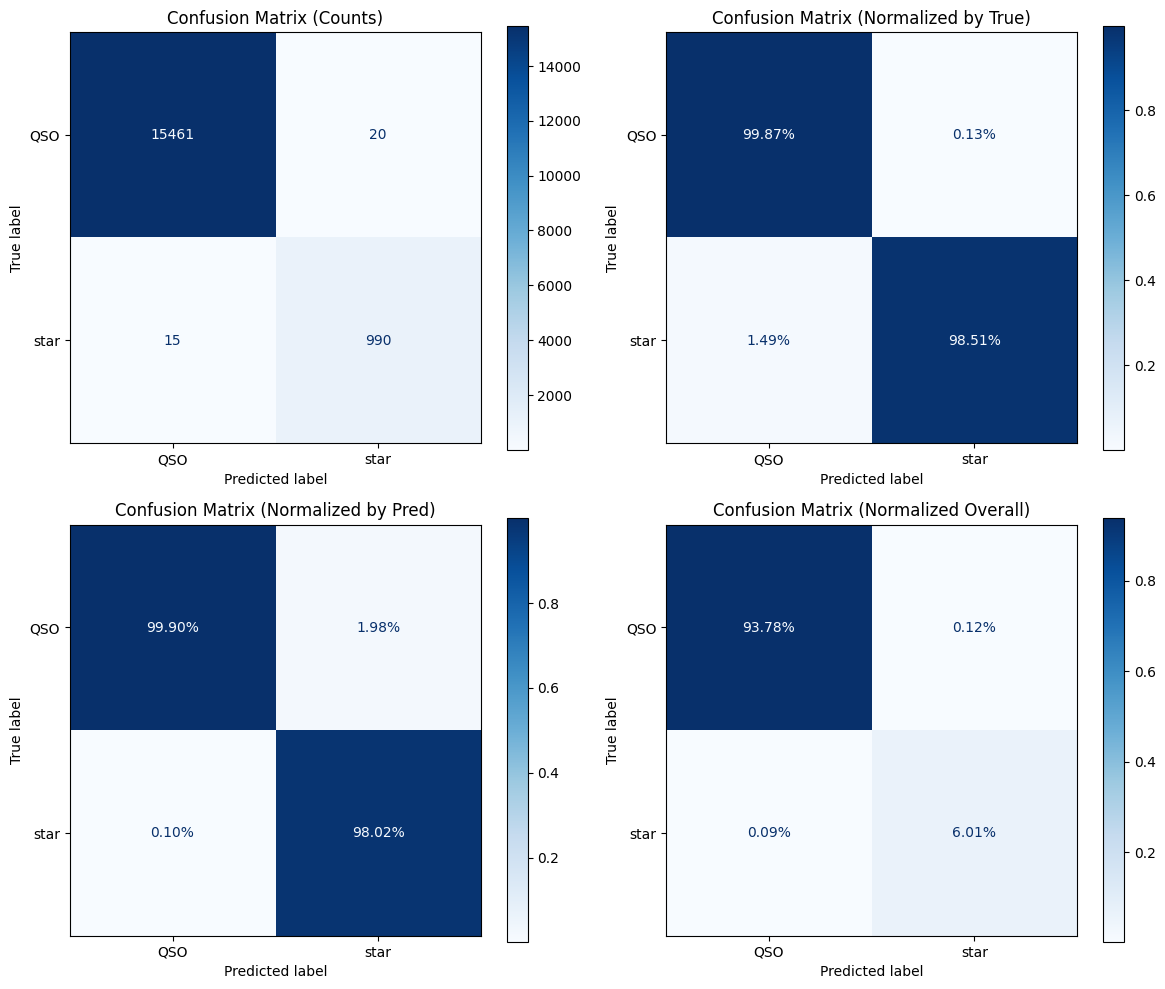

In [ ]:
# Get best parameters
best_params = study.best_params
print("\nBest Parameters Found by Optuna:", best_params)
print("Best ROC AUC Score from CV:", study.best_value)

# Train final model with best parameters
best_model = BalancedRandomForestClassifier(**best_params, random_state=8)
best_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_rbf_optuna = best_model.predict(X_test)
y_proba_rbf_optuna = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_ros, target_names=le.classes_))

print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_proba_ros):.4f}")

# Confusion Matrix
plot_four_confusion_matrices(y_test, y_pred_ros, le)

Finally, we can compare the differnet models explored. Note that these results do not necessarily represents the results that you will get everytime with any kind of dataset. It all depends on the model, the dataset you are working with, and how "messy" it is.

In [ ]:
# Compare all models
print(f"Test ROC AUC Score (sklearn-RF): {roc_auc_score(y_test, y_proba_simple_sk):.6f}")
print(f"Test ROC AUC Score (optuna-RF): {roc_auc_score(y_test, y_proba_simple_optuna):.6f}")
print(f"Test ROC AUC Score (rus-RF): {roc_auc_score(y_test, y_proba_rus):.6f}")
print(f"Test ROC AUC Score (ros-RF): {roc_auc_score(y_test, y_proba_ros):.6f}")
print(f"Test ROC AUC Score (brf-RF): {roc_auc_score(y_test, y_proba_brf):.6f}")
print(f"Test ROC AUC Score (optuna-brf): {roc_auc_score(y_test, y_proba_rbf_optuna):.6f}")

Test ROC AUC Score (sklearn-RF): 0.999862
Test ROC AUC Score (optuna-RF): 0.999862
Test ROC AUC Score (rus-RF): 0.999692
Test ROC AUC Score (ros-RF): 0.999853
Test ROC AUC Score (brf-RF): 0.999810
Test ROC AUC Score (optuna-brf): 0.999804
